# K Nearest Neighbours

In [65]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
import pickle

## Carga de datos

In [53]:
X_train = pd.read_csv('/workspaces/adamcn10-intro-ml/data/processed/knn-X-train.csv', index_col=[0])
X_test = pd.read_csv('/workspaces/adamcn10-intro-ml/data/processed/knn-X-test.csv', index_col=[0])
y_train = pd.read_csv('/workspaces/adamcn10-intro-ml/data/processed/knn-y-train.csv', index_col=[0])
y_test = pd.read_csv('/workspaces/adamcn10-intro-ml/data/processed/knn-y-test.csv', index_col=[0])

## Modelado

In [54]:
model = KNeighborsClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred

/home/vscode/.local/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1,
       2, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       2, 1, 1, 1, 1, 1, 1, 1])

In [55]:
model_accuracy = accuracy_score(y_test, y_pred)
model_accuracy

0.8272058823529411

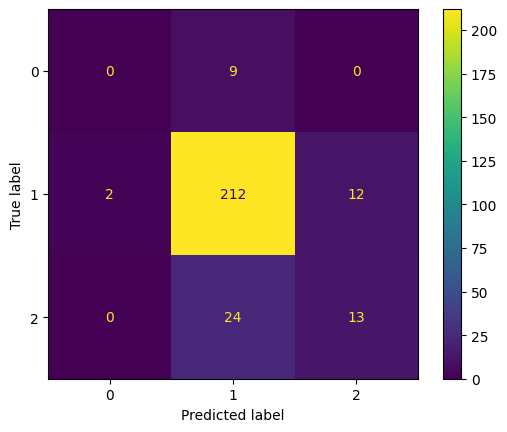

In [56]:
model_confusion_matrix = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(model_confusion_matrix).plot()
plt.show()

In [57]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.87      0.94      0.90       226
           2       0.52      0.35      0.42        37

    accuracy                           0.83       272
   macro avg       0.46      0.43      0.44       272
weighted avg       0.79      0.83      0.81       272



## Optimización del modelo (Hiperparametros)

In [58]:
hyperparams = {
    'n_neighbors': [5, 9, 15, 19, 25, 30, 35],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski', 'chebyshev', 'cosine'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1, 2]
}

In [59]:
grid = GridSearchCV(model, hyperparams, scoring = "accuracy", cv = 10)

In [60]:
grid.fit(X_train, y_train)

grid.best_params_

/home/vscode/.local/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/home/vscode/.local/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/home/vscode/.local/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/home/vscode/.local/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change 

{'algorithm': 'auto',
 'metric': 'euclidean',
 'n_neighbors': 25,
 'p': 1,
 'weights': 'distance'}

In [61]:
grid.best_estimator_

,n_neighbors,25
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [62]:
best = grid.best_estimator_
y_pred_best = best.predict(X_test)
grid_accuracy = accuracy_score(y_test, y_pred_best)
model_accuracy, grid_accuracy

(0.8272058823529411, 0.8419117647058824)

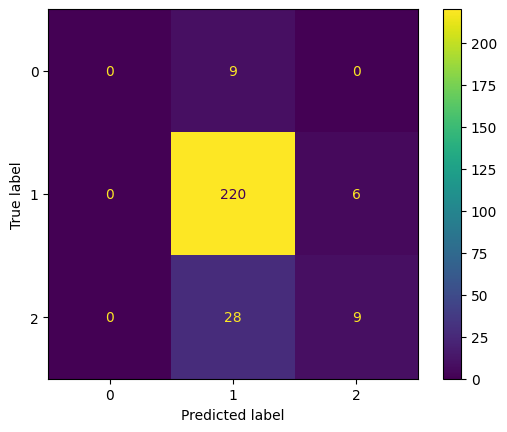

In [63]:
grid_confusion_matrix = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(grid_confusion_matrix).plot()
plt.show()

In [64]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.86      0.97      0.91       226
           2       0.60      0.24      0.35        37

    accuracy                           0.84       272
   macro avg       0.49      0.41      0.42       272
weighted avg       0.79      0.84      0.80       272



/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Comparación de modelos

>Hemos visto en las metricas que el modelo mejoraba con la hipermarametrizacuión con GridSearchCV, pasaba de una precisión de algo más de 0.82 a una superior al 0.84, aunque ambos modelos, tanto el optimizado como el base fallan mucho al tratar de clasificar los vinos de caldad baja y alta, es más, el optimizado clasifica mejor los de calidad media pero empeora respecto a los de caliad alta, siendo ambos negados en cuanto a predecir los de calidad baja.

## Guardado de modelos

In [66]:
with open('/workspaces/adamcn10-intro-ml/models/knn-model.pkl', 'wb') as file:
    pickle.dump(model, file)     

with open('/workspaces/adamcn10-intro-ml/models/knn-grid.pkl', 'wb') as file:
    pickle.dump(best, file)